### 1) DataFrame Initialization

In [1]:
import pandas as pd
df=pd.read_csv("Dataset/day-r5.2_raw.csv")

/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/nfsshare/users/P127015003/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### 2) Class Distribution

In [2]:
X = df.drop(columns=['insider'])
y = df['insider']

print("Original class distribution:")
print(y.value_counts())

Original class distribution:
insider
0    692342
2       863
4       339
1        85
3        20
Name: count, dtype: int64


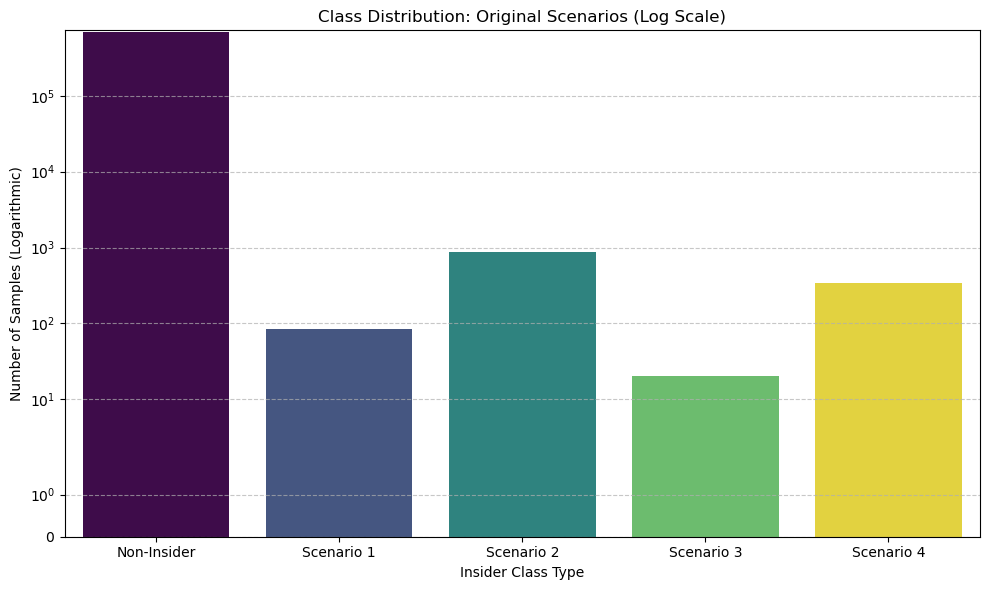

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='insider', data=df, hue='insider', palette='viridis', legend=False)

plt.yscale('symlog') 

plt.title("Class Distribution: Original Scenarios (Log Scale)")
plt.xlabel("Insider Class Type")
plt.ylabel("Number of Samples (Logarithmic)")

plt.xticks([0, 1, 2, 3, 4], ['Non-Insider', 'Scenario 1', 'Scenario 2', 'Scenario 3', 'Scenario 4'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("class_dist_raw_before.png", dpi=300, bbox_inches='tight')
plt.show()

In [4]:
y=y.replace({1:1, 2:1, 3:1, 4:1})
print(y.value_counts())

insider
0    692342
1      1307
Name: count, dtype: int64


In [5]:
df_updated = pd.concat([X, y], axis=1)

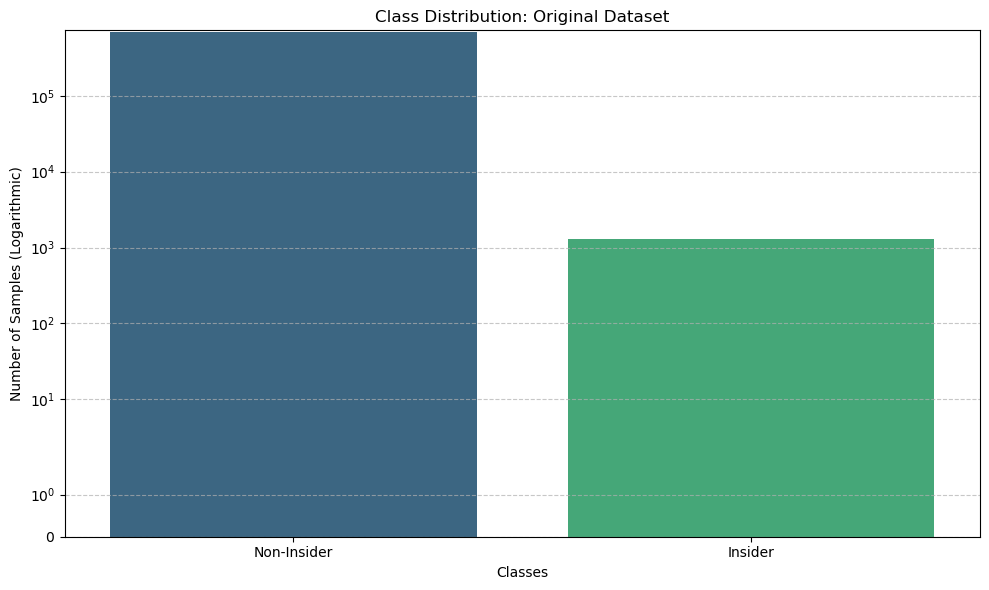

In [6]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='insider', data=df_updated, hue='insider', palette='viridis', legend=False)

plt.yscale('symlog') 

plt.title("Class Distribution: Original Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Samples (Logarithmic)")

plt.xticks([0, 1], ['Non-Insider', 'Insider'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("class_dist_raw_after.png", dpi=300, bbox_inches='tight')
plt.show()

### 3) SMOTE

In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=3, sampling_strategy="auto", random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)

X_smote = pd.DataFrame(X_smote, columns=X.columns)
X_smote['insider'] = y_smote

X_smote.to_csv("Dataset/dataset_smote.csv", index=False)

print("\nSMOTE dataset saved")
print("Final shape:", X_smote.shape)


SMOTE dataset saved
Final shape: (1384684, 830)


### 4) ADASYN

In [13]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(n_neighbors=5, sampling_strategy="auto", random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

X_adasyn = pd.DataFrame(X_adasyn, columns=X.columns)
X_adasyn['insider'] = y_adasyn

X_adasyn.to_csv("Dataset/dataset_adasyn.csv", index=False)

print("\nADASYN dataset saved")
print("Final shape:", X_adasyn.shape)



ADASYN dataset saved
Final shape: (1384164, 830)


### 5) Cluster Centroids

In [5]:
from imblearn.under_sampling import ClusterCentroids

cc = ClusterCentroids(random_state=42)

X_cc, y_cc = cc.fit_resample(X, y)

X_cc = pd.DataFrame(X_cc, columns=X.columns)
X_cc['insider'] = y_cc

X_cc.to_csv("Dataset/dataset_cluster_centroids.csv", index=False)

print("\nCluster Centroids dataset saved")
print("Final shape:", X_cc.shape)



Cluster Centroids dataset saved
Final shape: (2614, 830)


### 6) Edited Nearest Neighbors

In [13]:
# from imblearn.under_sampling import EditedNearestNeighbours

# enn = EditedNearestNeighbours(n_neighbors=3, kind_sel='mode', sampling_strategy="majority")

# X_enn, y_enn = enn.fit_resample(X, y)

# X_enn = pd.DataFrame(X_enn, columns=X.columns)
# X_enn['insider'] = y_enn

# X_enn.to_csv("Dataset/dataset_enn.csv", index=False)

# print("\nEdited Nearest Neighbors dataset saved")
# print("Final shape:", X_enn.shape)

In [7]:
# from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
# import pandas as pd

# total_target = 58409+165
# minority_count = (y == 1).sum()  

# majority_to_keep = total_target - minority_count 

# print(f"Minority samples: {minority_count}")
# print(f"Majority samples to keep: {majority_to_keep}")

# strategy = {0: majority_to_keep, 1: minority_count}
# rus = RandomUnderSampler(sampling_strategy=strategy, random_state=42)
# X_res, y_res = rus.fit_resample(X, y)

# enn = EditedNearestNeighbours(
#     n_neighbors=3, 
#     kind_sel='mode', 
#     sampling_strategy='majority'
# )
# X_enn, y_enn = enn.fit_resample(X_res, y_res)

# X_final = pd.DataFrame(X_enn, columns=X.columns)
# X_final['insider'] = y_enn

# X_final.to_csv("Dataset/dataset_enn_final.csv", index=False)

# print("\nEdited Nearest Neighbors dataset saved")
# print("Final shape:", X_final.shape)

Minority samples: 1307
Majority samples to keep: 57267

Edited Nearest Neighbors dataset saved
Final shape: (58409, 830)


In [9]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.utils import resample

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_sm, y_sm = smote.fit_resample(X, y)

enn = EditedNearestNeighbours(
    n_neighbors=3, 
    kind_sel='mode', 
    sampling_strategy='majority'
)
X_enn, y_enn = enn.fit_resample(X_sm, y_sm)

df_temp = pd.DataFrame(X_enn, columns=X.columns)
df_temp['insider'] = y_enn

df_0 = df_temp[df_temp['insider'] == 0]
df_1 = df_temp[df_temp['insider'] == 1]

n_0 = 58409 // 2
n_1 = 58409 - n_0

df_0_final = resample(df_0, replace=False, n_samples=n_0, random_state=42)
df_1_final = resample(df_1, replace=False, n_samples=n_1, random_state=42)

X_final = pd.concat([df_0_final, df_1_final]).sample(frac=1, random_state=42)

X_final.to_csv("Dataset/dataset_enn.csv", index=False)

print(f"Final Dataset Shape: {X_final.shape}")
print("Class Distribution:")
print(X_final['insider'].value_counts())

Final Dataset Shape: (58409, 830)
Class Distribution:
insider
1    29205
0    29204
Name: count, dtype: int64
